# DEF-D Fysieke Ontwerpopdracht 5 Invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 4     |  |
| :-------------|:-------------|
| Frank de Kogel | 6582737 |
| Moos Stoop | 6525474 |
| Justin Sloots | 6541313 |

## Opdracht 1: Planning.

| Planning Groep: 4     |Tijdstip / Tijdspanne  | door wie  |
|---|---|---|
| Arduino testen| 11:00 | Frank |
| ontwerp-eis berekenen| 11:15 | Justin en Moos|
| parameters bepalen | 11:15-11:45 | hele groep |
| schattend rekenen | 11:45-12:30 | hele groep |
| synthese schets | 14:00 | ---|
| werkende demper | 16:30 | ---|
| Pauze 1| 12:30-13:30 | hele groep |
| Pauze 2| 15:30-15:45 | hele groep |

Run onderstaande cel om alle benodigde libraries te laden. Mogelijk voeg je er zelf nog een aantal toe later vandaag. 

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
import math

## Opdracht 2a: Opsplitsen taak 1: Arduino
Vul onderstaande tabel in:

| onderwerp    | antwoord  |
|---|---|
| hoe moeilijk (schaal 1 - 10) | 2 |
| hoe lang voor één meting | 1 minuut |
| verwacht nauwkeurigheid meting | frequentie binnen 0.2 Hz en Amplitude binnen 0.3 m/s^2 |

## Opdracht 2b: Opsplitsen taak 2: afleiding ontwerpeis

In [2]:
# Bereken hier je benodigde kantelfrequentie
f_0 = 5 #Hz
verhouding = 1/3
w = 2*np.pi*5

w0 = np.sqrt((w**2)/((1/verhouding)+1))

print(w0/np.pi, "pi")
#C < 246.7*m 

5.0 pi


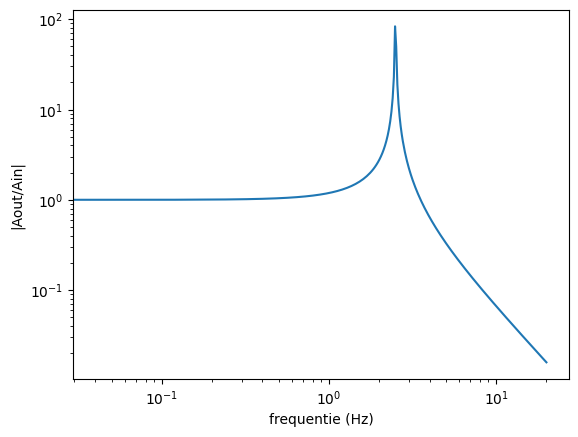

0.3333333333333333


In [3]:
def Verhouding(f):
    return np.abs(1/(1-((2*np.pi*f)**2)/(w0**2)))

x_test = np.linspace(0, 20,500)
y_test = Verhouding(x_test)

plt.figure()
plt.loglog(x_test, y_test)
plt.ylabel("|Aout/Ain|")
plt.xlabel("frequentie (Hz)")
plt.show()

print(Verhouding(5))

In [4]:
g = 9.81

delta_x = g/(w0**2)

print(delta_x)

g = 9.81
w0_2 = 4*np.pi
delta_x = g/(w0_2**2)

print(delta_x)

0.039758432461253344
0.06212255072070835


## Opdracht 3: Plot de grafiek.

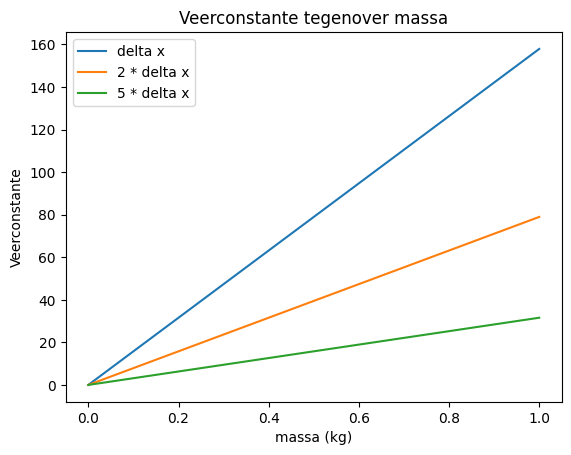

In [5]:
# Voeg hier je plot in. Lees goed de opdracht wat er in de grafiek moet staan!
# Het is ook handig om je grafiek op te slaan, doe dat door met plt.savefig().

def Veerconstante(m,delta_x):
    return (m*9.81)/delta_x


delta_x_2 = 2*delta_x
delta_x_5 = 5*delta_x

m = np.linspace(0,1,1000)
C = Veerconstante(m, delta_x)
C_2 = Veerconstante(m, delta_x_2)
C_3 = Veerconstante(m, delta_x_5)

plt.figure()
plt.plot(m, C, label = "delta x")
plt.plot(m, C_2, label = "2 * delta x")
plt.plot(m, C_3, label = "5 * delta x")
plt.ylabel("Veerconstante")
plt.xlabel("massa (kg)")
plt.title("Veerconstante tegenover massa")
plt.legend()
plt.savefig("Plot_met_delta_x")
plt.show()

## Opdracht 4: Verander $\Delta x$.

We kunnen $\Delta x$ verhogen door:

- Zwakkere veer
- Meer massa

Vul onderstaande aan. Geef eventueel met tekst aan waarom je hiervoor gekozen hebt, als extra informatie richting de nakijkers. 

Als groep gaan we mikken op een $\Delta x$ van: 8 cm, want dan zitten we ruim boven de 3 keer demping

## Opdracht 5: Schets.

##### schets opstelling: 
<img src="opstelling-FysOpdr5.jpeg" width="400">

## Opdracht 6: Beslissing evaluatie

Voldoet je ontwerp aan de eisen? Beantwoord de volgende vragen:

### Wat is de $\Delta x$ van je ontwerp?

8cm

### Wordt die $\Delta x$ behaald met je gekozen massa en veer?

Ja, we behalen een $\Delta x$ van 8 cm

### hoeveel verder kan je massa-veer systeem nog uitrekken / indrukken?
Wat is de limiet aan je veer / verend materiaal voordat het niet meer lineair reageert volgens de wet van Hooke?

12 cm voordat de vloer wordt geraakt.


### Is dat genoeg om straks metingen te kunnen doen?
Hou er rekening mee dat je trillingen een amplitude in de orde grote van een paar centimeter gaan hebben, minder is met deze opzet moeilijk te realiseren.

Ja, er is nog genoeg ruimte om de veer en massa.

### Gaat je ontwerp dus voldoen aan de eis?

Ja.

Als je hier positief geantwoord heb, maak dan nog een keer een plot van amplitude overdracht (y-as) versus frequentie (x-as) zoals je hierboven ook al een keer gedaan heb, maar plot nu twee verschillende overdrachten in de grafiek: één die je al had: behorende bij de grens van de ontwerp-eis en één behorende bij je eigen ontwerp. Lees af dat je voor je ontwerp daadwerkelijk onder de eis grafiek zit op de kritieke frequentie!

Deze grafiek heb je later weer nodig om je gemeten punten aan toe te voegen. Ga daarna je massa-veer systeem daadwerkelijk bouwen.

Als je hier negatief geantwoord hebt, kopieer onder deze cel dan alle cellen van Synthese tot en met Evaluation & decision en doorloop dat deel van het ontwerp proces nogmaals.

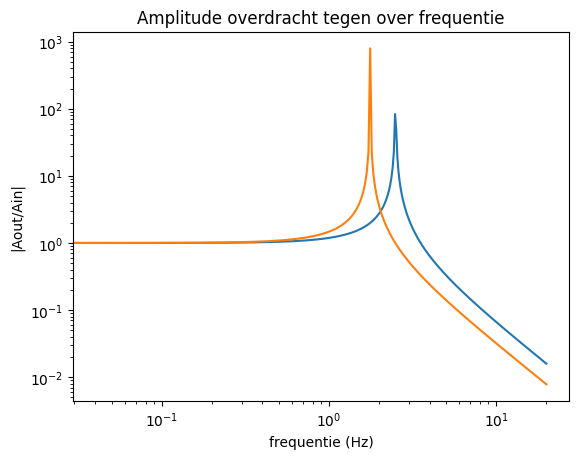

In [6]:
w0_opstelling = np.sqrt(9.81/0.08)

def Verhouding(f,w0):
    return np.abs(1/(1-((2*np.pi*f)**2)/(w0**2)))

x_sim = np.linspace(0, 20,500)
y_sim = Verhouding(x_sim, w0_opstelling)

plt.figure()
plt.loglog(x_test, y_test)
plt.loglog(x_sim, y_sim)
plt.ylabel("|Aout/Ain|")
plt.xlabel("frequentie (Hz)")
plt.savefig("Plot_met_simulatie")
plt.title("Amplitude overdracht tegen over frequentie")
plt.show()


## Opdracht 7: Plotten maar

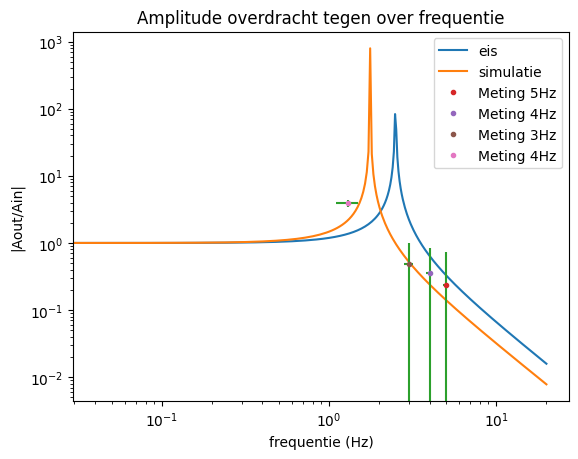

In [7]:
x_data = np.array([5,4,3,1.3])
y_data = np.array([1.26/5.42, 1.54/4.36, 1.09/2.25, 0.7/0.18])

plt.figure()
plt.loglog(x_test, y_test, label = "eis")
plt.loglog(x_sim, y_sim, label = "simulatie")
plt.errorbar(xerr=0.2, yerr=0.5,x= x_data, y= y_data, linestyle='None' )
plt.loglog(5,1.26/5.42, ".", label = "Meting 5Hz")
plt.loglog(4,1.54/4.36, ".", label = "Meting 4Hz")
plt.loglog(3,1.09/2.25, ".", label = "Meting 3Hz")
plt.loglog(1.3,0.7/0.18, ".", label = "Meting 4Hz")
plt.ylabel("|Aout/Ain|")
plt.xlabel("frequentie (Hz)")
plt.title("Amplitude overdracht tegen over frequentie")
plt.legend()
plt.savefig("Plot_met_meetpunten")
plt.show()


## Opdracht 8: Leerdoelen
Voeg hieronder zelf kopjes toe om aan te geven wat bij welk leerdoel hoort. 

In [8]:
# Als je met Python je resultaten wil laten zien: voeg hier je code in.

#### Als je je figuren onderweg opgeslagen hebt, kan je ze hier invoegen:
##### Inzien dat de parameters in een differentiaalvergelijking ontwerpparameters zijn die een ontwerpruimte opspannen:

<img src="Plot_met_delta_x.png" width="400">

##### Op basis van een differentiaal vergelijking een keuze maken voor parameters en die vervolgens kunnen vertalen in een fysiek ontwerp:

<img src="Plot_met_meetpunten.png" width="400">

Als bonus hebben wij ook een dempingsfactor van 50 behaald door in het trapgat te gaan zitten.